In [294]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures


In [295]:
df = pd.read_csv('housing.csv')

In [296]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [297]:
df.head(5)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [298]:
new_furniture = pd.get_dummies(df['furnishingstatus'])

In [299]:
df = pd.concat([df,new_furniture],axis = 1)

In [300]:
df.drop('furnishingstatus',axis = 1 ,inplace=True)

In [301]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnished,semi-furnished,unfurnished
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,True,False,False
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,True,False,False
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,False,True,False
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,True,False,False
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,True,False,False


In [302]:
l1_yes = df[['mainroad','airconditioning','prefarea']]
l1_no = df[['guestroom','basement','hotwaterheating']]


In [303]:
for x in l1_no:
    df[x] = df[x].map({'no':0,'yes':1})
for s in l1_yes:
    df[s] = df[s].map({'yes':1,'no':0})

In [304]:
df.head(5)
l3 = df[['furnished','semi-furnished','unfurnished']]
for t in l3:
    df[t] = df[t].astype(int)
print(df.dtypes)

price              int64
area               int64
bedrooms           int64
bathrooms          int64
stories            int64
mainroad           int64
guestroom          int64
basement           int64
hotwaterheating    int64
airconditioning    int64
parking            int64
prefarea           int64
furnished          int64
semi-furnished     int64
unfurnished        int64
dtype: object


In [305]:
X = df.drop('price',axis=1)
y=df['price']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [306]:
lr = LinearRegression()

In [307]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [308]:
y_pred = lr.predict(X_test)

In [309]:
print("Mean absolute error: ",mean_absolute_error(y_test,y_pred))
print("mean square error: ",mean_squared_error(y_test,y_pred))
print("R2 Score: ",r2_score(y_test,y_pred))

Mean absolute error:  970043.403920164
mean square error:  1754318687330.6638
R2 Score:  0.6529242642153184


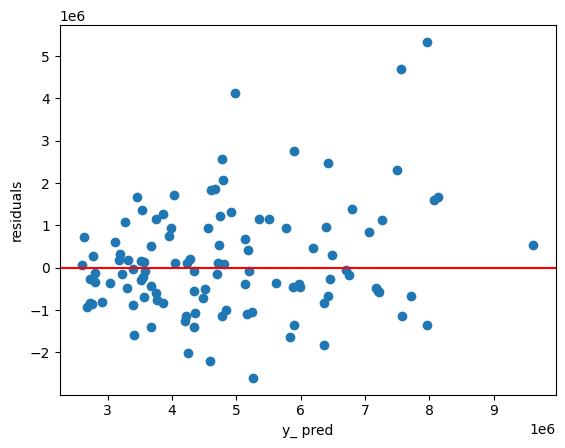

In [310]:
residuals  = y_test - y_pred
plt.scatter(y_pred,residuals)
plt.axhline(color = 'red')
plt.xlabel('y_ pred')
plt.ylabel("residuals")
plt.show()

In [311]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cross_val = cross_val_score(
    lr,
    X,
    y,
    cv = kf,
    scoring = "r2"
)

print(cross_val)
print(cross_val.mean())

[0.65292426 0.71208274 0.49275519 0.65803892 0.64643709]
0.6324476415125714


In [312]:
print(lr.score(X_train, y_train))
print(lr.score(X_test, y_test))
print(y.describe())

0.6859438988560159
0.6529242642153184
count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64


In [313]:
df.columns
print(r2_score(y_test, y_pred))

0.6529242642153184


{'whiskers': [<matplotlib.lines.Line2D at 0x2f0f30d8050>,
 'caps': [<matplotlib.lines.Line2D at 0x2f0f30d82f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2f0f306be00>],
 'medians': [<matplotlib.lines.Line2D at 0x2f0f30d8590>],
 'fliers': [<matplotlib.lines.Line2D at 0x2f0f30d86e0>],
 'means': []}

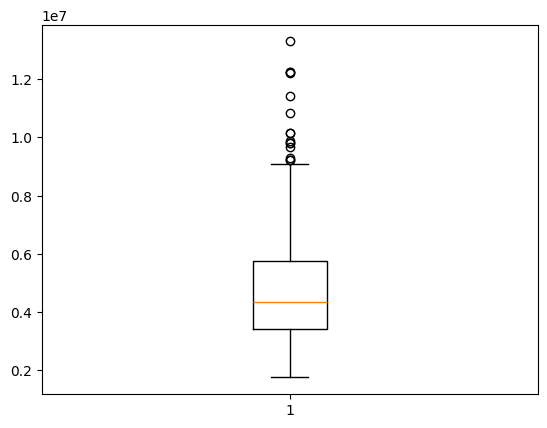

In [281]:
plt.boxplot(df['price'])